Day 1 - Tesing with the model

In [ ]:
!nvidia-smi

Thu Mar 19 03:42:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Must uninstall first to avoid version conflicts, then reinstall everything cleanly
!pip uninstall bitsandbytes -y -q

!pip install -q \
  transformers \
  datasets \
  accelerate \
  bitsandbytes \
  peft \
  trl \
  sentencepiece \
  scipy \
  scikit-learn

In [ ]:
!pip install rouge-score bert-score -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.9 MB/s eta 0:00:00


Restart the runtime

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

print("GPU:", torch.cuda.get_device_name(0))

GPU: Tesla T4


In [ ]:
# model_name = "mistralai/Mistral-7B-Instruct-v0.2"

# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.float16,
#     bnb_4bit_use_double_quant=True
# )

# model = AutoModelForCausalLM.from_pretrained(
#     model_name,
#     quantization_config=bnb_config,
#     device_map="auto"
# )

In [ ]:
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# tokenizer.padding_side = "left"
# tokenizer.pad_token = tokenizer.eos_token

In [ ]:
# messages = [
#     {
#         "role": "system",
#         "content": "You are a medical assistant that explains clinical text in simple language for patients."
#     },
#     {
#         "role": "user",
#         "content": "Simplify this clinical sentence: The patient presents with hyperglycemia secondary to insulin resistance."
#     }
# ]

# prompt = tokenizer.apply_chat_template(
#     messages,
#     tokenize=False,
#     add_generation_prompt=True
# )

# print(prompt)

In [ ]:
# inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

In [ ]:
# outputs = model.generate(
#     **inputs,
#     max_new_tokens=120,
#     temperature=0.7,
#     do_sample=True
# )

# result = tokenizer.decode(outputs[0], skip_special_tokens=True)

# print(result)

In [ ]:
# baseline_outputs = []

# baseline_outputs.append({
#     "clinical_text": "The patient presents with hyperglycemia secondary to insulin resistance.",
#     "baseline_model_output": result
# })

# baseline_outputs

In [ ]:
!nvidia-smi

Thu Mar 19 03:43:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Day 2- Dataset pipeline

In [ ]:
from datasets import load_dataset

ds = load_dataset("armanc/pubmed-rct20k")

print(ds)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/646 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/40.7M [00:00<?, ?B/s]

...

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/176642 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/29672 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/29578 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 176642
    })
    validation: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29672
    })
    test: Dataset({
        features: ['abstract_id', 'label', 'text', 'sentence_id'],
        num_rows: 29578
    })
})


In [ ]:
ds["train"][0]

{'abstract_id': '24293578',
 'label': 'objective',
 'text': 'To investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .',
 'sentence_id': 0}

In [ ]:
biomedical_sentences = []

for example in ds["train"]:

    sentence = example["text"]

    if len(sentence) > 80:
        biomedical_sentences.append(sentence)

    if len(biomedical_sentences) >= 3000:
        break

print("Collected:", len(biomedical_sentences))

Collected: 3000


In [ ]:
import re

def clean_text(text):

    text = text.replace("@", "")
    text = text.replace("-LSB-", "")
    text = text.replace("-RSB-", "")

    text = re.sub(r"\s+", " ", text)

    return text.strip()


cleaned_sentences = [clean_text(s) for s in biomedical_sentences]

In [ ]:
import random

for _ in range(5):
    print(random.choice(cleaned_sentences))

The effect of oral polio vaccine administered already at birth ( OPV ) on child survival was not examined before being recommended in .
Serum calcium , phosphorus and alkaline phosphatase levels as well as growth parameters ( including weight , height , and head circumference ) were measured every two weeks .
Timely angiography and revascularization were often not achieved in transferred patients .
Audiotaped interviews were transcribed , translated , and coded thematically for analysis .
The postoperative bleeding of the two groups were scored by visual analogue scale .


In [ ]:
paragraph_inputs = []

for i in range(0, 450, 3):

    paragraph = " ".join(cleaned_sentences[i:i+3])

    if len(paragraph) > 150:
        paragraph_inputs.append(paragraph)

print("Paragraphs:", len(paragraph_inputs))

Paragraphs: 150


In [ ]:
sentence_inputs = cleaned_sentences[:250]

print("Sentence samples:", len(sentence_inputs))

Sentence samples: 250


In [ ]:
inputs = sentence_inputs + paragraph_inputs

print("Total inputs:", len(inputs))

Total inputs: 400


In [ ]:
# import torch
# from transformers import AutoTokenizer, AutoModelForCausalLM

# model_id = "Qwen/Qwen2.5-7B-Instruct"

# tokenizer = AutoTokenizer.from_pretrained(model_id)

# model = AutoModelForCausalLM.from_pretrained(
#     model_id,
#     torch_dtype=torch.float16,
#     device_map="auto"
# )


# Skipping Qwen teacher model — all synthetic data generation (Cells 26-32) is commented out.
# Loading a 7B fp16 model here uses ~14 GB and will OOM a T4.
# Dataset is uploaded manually via Cell 35 instead.
print("Skipping Qwen teacher model. Dataset will be uploaded manually later on.")

Skipping Qwen teacher model. Dataset will be uploaded manually later on.


In [ ]:
import torch

def simplify_text(batch):

    prompts = [
        f"""Rewrite the biomedical text so that a patient can understand it.

Rules:
- Use simple language
- Do not add medical advice
- Do not add new facts
- Preserve disease and drug names

Biomedical text:
{text}

Patient explanation:"""
        for text in batch
    ]

    tokens = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **tokens,
            max_new_tokens=120,
            do_sample=False,
            # temperature=0.0,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)

    results = []
    for d in decoded:
        results.append(d.split("Patient explanation:")[-1].strip())

    return results

In [ ]:
# outputs = []

# batch_size = 8

# for i in range(0, len(inputs), batch_size):

#     batch = inputs[i:i+batch_size]

#     batch_outputs = simplify_text(batch)

#     outputs.extend(batch_outputs)

#     print(f"Processed {min(i+batch_size, len(inputs))}/{len(inputs)}")

In [ ]:
# dataset = []

# for inp, out in zip(inputs, outputs):

#     dataset.append({
#         "instruction": "Simplify the clinical text so a patient can understand it.",
#         "input": inp,
#         "output": out
#     })
# print(len(dataset))

In [ ]:
# import json
# with open("medical_simplification_dataset.jsonl", "w") as f:
#     for row in dataset:
#         f.write(json.dumps(row) + "\n")

# print("Dataset saved")

In [ ]:
# from sklearn.model_selection import train_test_split

# train_data, val_data = train_test_split(
#     dataset,
#     test_size=0.1,
#     random_state=42
# )

# print(len(train_data), len(val_data))

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# import json

# path = "/content/drive/MyDrive/medical_simplification_dataset.jsonl"

# with open(path, "w") as f:
#     for row in dataset:
#         f.write(json.dumps(row) + "\n")

# print("Saved to Google Drive")

In [ ]:
# from datasets import load_dataset

# dataset = load_dataset(
#     "json",
#     data_files="/content/drive/MyDrive/medical_simplification_dataset.jsonl"
# )

Day 3 - SFT Training

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving medical_simplification_dataset.jsonl to medical_simplification_dataset.jsonl


In [ ]:
# medical_simplification_dataset.jsonl

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="medical_simplification_dataset.jsonl"
)

dataset

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 400
    })
})

In [ ]:
dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)

dataset

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 360
    })
    test: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 40
    })
})

In [ ]:
dataset["validation"] = dataset.pop("test")

In [ ]:
dataset["train"][0]

{'instruction': 'Simplify the clinical text so a patient can understand it.',
 'input': 'Group ( provider only ) delivered MI counseling sessions to parents of the index child over years . Group ( provider + RD ) delivered provider MI sessions plus MI sessions from a RD. . At -year follow-up , the adjusted BMI percentile was , , and for groups , , and , respectively .',
 'output': "Parents got help talking about heart problems with their kids from doctors over many years. Some parents also got extra help from a special dietitian. When we checked back after a few years, the kids' body size (measured by something called BMI) was better for all groups, but it was best for the group that got help from both the doctor and the dietitian. The numbers are: Group 1: ___, Group 2: ___, and Group 3: ____.\nYou can fill in the blanks with the actual numbers when you have them. \n\nNote: The actual numbers were"}

In [ ]:
from transformers import AutoTokenizer

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

In [ ]:
def format_chat(example):

    messages = [
        {"role": "system", "content": example["instruction"]},
        {"role": "user", "content": example["input"]},
        {"role": "assistant", "content": example["output"]}
    ]

    example["text"] = tokenizer.apply_chat_template(
        messages,
        tokenize=False
    )

    return example

In [ ]:
dataset = dataset.map(format_chat)

Map:   0%|          | 0/360 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

In [ ]:
print(dataset["train"][0]["text"])

<s> [INST] Simplify the clinical text so a patient can understand it.

Group ( provider only ) delivered MI counseling sessions to parents of the index child over years . Group ( provider + RD ) delivered provider MI sessions plus MI sessions from a RD. . At -year follow-up , the adjusted BMI percentile was , , and for groups , , and , respectively . [/INST] Parents got help talking about heart problems with their kids from doctors over many years. Some parents also got extra help from a special dietitian. When we checked back after a few years, the kids' body size (measured by something called BMI) was better for all groups, but it was best for the group that got help from both the doctor and the dietitian. The numbers are: Group 1: ___, Group 2: ___, and Group 3: ____.
You can fill in the blanks with the actual numbers when you have them. 

Note: The actual numbers were</s>


In [ ]:
dataset["train"].column_names

['instruction', 'input', 'output', 'text']

In [ ]:
for i in range(3):
    print(dataset["train"][i]["text"])
    print("\n---\n")

<s> [INST] Simplify the clinical text so a patient can understand it.

Group ( provider only ) delivered MI counseling sessions to parents of the index child over years . Group ( provider + RD ) delivered provider MI sessions plus MI sessions from a RD. . At -year follow-up , the adjusted BMI percentile was , , and for groups , , and , respectively . [/INST] Parents got help talking about heart problems with their kids from doctors over many years. Some parents also got extra help from a special dietitian. When we checked back after a few years, the kids' body size (measured by something called BMI) was better for all groups, but it was best for the group that got help from both the doctor and the dietitian. The numbers are: Group 1: ___, Group 2: ___, and Group 3: ____.
You can fill in the blanks with the actual numbers when you have them. 

Note: The actual numbers were</s>

---

<s> [INST] Simplify the clinical text so a patient can understand it.

However , it is unclear whether th

In [ ]:
# import torch
# from transformers import AutoModelForCausalLM, BitsAndBytesConfig
# from peft import prepare_model_for_kbit_training

In [ ]:
# import bitsandbytes as bnb
# print(bnb.__version__)

In [ ]:
import gc, torch

if 'model' in globals():
    del model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# from transformers import AutoModelForCausalLM, BitsAndBytesConfig
# import torch

# bnb_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_quant_type="nf4",
#     bnb_4bit_compute_dtype=torch.float16,
#     bnb_4bit_use_double_quant=True
# )

# model = AutoModelForCausalLM.from_pretrained(
#     model_name,
#     quantization_config=bnb_config,
#     device_map="auto",
#     trust_remote_code=True,
#     low_cpu_mem_usage=True
# )

# # 52th cell

In [ ]:
# model.config.use_cache = False

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

torch.backends.cuda.matmul.allow_tf32 = True

In [ ]:
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model

# Step 1: prepare for kbit
# model = prepare_model_for_kbit_training(
#     model,
#     use_gradient_checkpointing=True,
#     gradient_checkpointing_kwargs={"use_reentrant": False}
# )

# Cell 56

In [ ]:
# print(model.device)

In [ ]:
!nvidia-smi

Thu Mar 19 03:44:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [ ]:
# model = get_peft_model(model, lora_config)

In [ ]:
# model.print_trainable_parameters()

In [ ]:
# from trl import SFTConfig

# training_args = SFTConfig(
#     dataset_text_field="text",
#     max_length=512,

#     output_dir="./mistral-medical-simplifier",
#     per_device_train_batch_size=2,
#     per_device_eval_batch_size=2,
#     gradient_accumulation_steps=4,
#     num_train_epochs=3,
#     learning_rate=2e-4,

#     fp16=True,
#     bf16=False,

#     optim="paged_adamw_8bit",

#     logging_steps=10,
#     eval_strategy="steps",
#     eval_steps=50,
#     save_strategy="epoch",
#     warmup_steps=50,
#     lr_scheduler_type="cosine",
#     report_to="none"
# )

In [ ]:
# from trl import SFTTrainer

# trainer = SFTTrainer(
#     model=model,
#     processing_class=tokenizer,
#     train_dataset=dataset["train"],
#     eval_dataset=dataset["validation"],
#     args=training_args
# )

# Cell 67

In [ ]:
  # trainer.train()

In [ ]:
# 68  -----------

In [ ]:
# trainer.model.save_pretrained("mistral-medical-lora")
# tokenizer.save_pretrained("mistral-medical-lora")

In [ ]:
# 70

In [ ]:
# from google.colab import files
# import shutil

# shutil.make_archive("mistral-medical-lora", 'zip', "mistral-medical-lora")
# files.download("mistral-medical-lora.zip")

Day 4- Evaluation

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="medical_simplification_dataset.jsonl"
)

dataset = dataset["train"]

print(dataset[0])
print("Dataset size:", len(dataset))

{'instruction': 'Simplify the clinical text so a patient can understand it.', 'input': 'To investigate the efficacy of weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .', 'output': "We want to see if giving older people with bad knee pain a small amount of a medicine called prednisolone every day for a few weeks helps make their knees less sore, easier to move, and reduces any low-level swelling. We'll check if these improvements last for several more weeks.\nYou're going to help us test if a little bit of a medicine called prednisolone, taken every day for a few weeks, can make your knees feel better and move easier. We want to know if this helps with the pain and swelling in your knees, and if those good effects stay"}
Dataset size: 400


In [ ]:
import pandas as pd

eval_df = pd.DataFrame({
    "clinical_text": [x["input"] for x in dataset],
    "reference_simplification": [x["output"] for x in dataset]
})

eval_df.head()

,clinical_text,reference_simplification
0,To investigate the efficacy of weeks of daily ...,We want to see if giving older people with bad...
1,A total of patients with primary knee OA were ...,Patients with knee pain from osteoarthritis (O...
2,Outcome measures included pain reduction and i...,The doctors will look at how much your pain go...
3,Secondary outcome measures included the Wester...,The doctors also looked at how bad your knee p...
4,"Serum levels of interleukin ( IL- ) , IL- , tu...",We checked the amounts of some special substan...


In [ ]:
# Cell 74

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving medical_simplification_dataset.jsonl to medical_simplification_dataset (1).jsonl


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving mistral-medical-lora.zip to mistral-medical-lora.zip


In [ ]:
!unzip mistral-medical-lora.zip

Archive:  mistral-medical-lora.zip
  inflating: chat_template.jinja     
  inflating: tokenizer.json          
  inflating: adapter_model.safetensors  
  inflating: tokenizer_config.json   
  inflating: adapter_config.json     
  inflating: README.md               


In [ ]:
!mkdir -p mistral-medical-lora && mv adapter_config.json adapter_model.safetensors tokenizer.json tokenizer_config.json chat_template.jinja README.md mistral-medical-lora/

In [ ]:
!ls mistral-medical-lora

adapter_config.json	   chat_template.jinja	tokenizer_config.json
adapter_model.safetensors  README.md		tokenizer.json


In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "json",
    data_files="medical_simplification_dataset.jsonl"
)

dataset = dataset["train"]

print("Dataset size:", len(dataset))
print(dataset[0])

Dataset size: 400
{'instruction': 'Simplify the clinical text so a patient can understand it.', 'input': 'To investigate the efficacy of weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .', 'output': "We want to see if giving older people with bad knee pain a small amount of a medicine called prednisolone every day for a few weeks helps make their knees less sore, easier to move, and reduces any low-level swelling. We'll check if these improvements last for several more weeks.\nYou're going to help us test if a little bit of a medicine called prednisolone, taken every day for a few weeks, can make your knees feel better and move easier. We want to know if this helps with the pain and swelling in your knees, and if those good effects stay"}


In [ ]:
import pandas as pd

eval_df = pd.DataFrame({
    "clinical_text": [x["input"] for x in dataset],
    "reference": [x["output"] for x in dataset]
})

eval_df.head()

,clinical_text,reference
0,To investigate the efficacy of weeks of daily ...,We want to see if giving older people with bad...
1,A total of patients with primary knee OA were ...,Patients with knee pain from osteoarthritis (O...
2,Outcome measures included pain reduction and i...,The doctors will look at how much your pain go...
3,Secondary outcome measures included the Wester...,The doctors also looked at how bad your knee p...
4,"Serum levels of interleukin ( IL- ) , IL- , tu...",We checked the amounts of some special substan...


In [ ]:
eval_df = eval_df.sample(100, random_state=42).reset_index(drop=True)

print("Evaluation samples:", len(eval_df))

Evaluation samples: 100


In [ ]:
import gc, torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

# Clear any stale memory before loading
if 'model' in globals():
    del model
gc.collect()
torch.cuda.empty_cache()

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True   # ← saves ~0.4GB extra vs your original
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True
)

# Load your trained LoRA adapter on top
# model = PeftModel.from_pretrained(base_model, "mistral-medical-lora")
# model.eval()

print("Model loaded successfully")
print(f"GPU memory used: {torch.cuda.memory_allocated()/1e9:.2f} GB")

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Model loaded successfully
GPU memory used: 4.13 GB


In [ ]:
def create_prompt(text):
    prompt = f"""<s>[INST] Simplify the clinical text so a patient can understand it.

{text}

[/INST]"""
    return prompt

In [ ]:
text = eval_df["clinical_text"][0]

prompt = create_prompt(text)

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = base_model.generate(
    **inputs,
    max_new_tokens=150,
    do_sample=True,       # required for temperature to take effect
    temperature=0.3
)

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(response)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[INST] Simplify the clinical text so a patient can understand it.

Oral administration of SMT was considered safe and well tolerated and was associated with negligible plasma concentrations after single and multiple doses .

[/INST] Taking the medicine SMT by mouth is generally safe and most people can tolerate it well. The amount of SMT that gets into your bloodstream is very low after taking it once or multiple times.


In [ ]:
baseline_outputs = []

for text in eval_df["clinical_text"][:20]:

    prompt = create_prompt(text)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = base_model.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=True,       # required for temperature to take effect
        temperature=0.3
    )

    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )

    baseline_outputs.append(response)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

In [ ]:
eval_df.loc[:19, "baseline_output"] = baseline_outputs

In [ ]:
from peft import PeftModel

# finetuned_model = PeftModel.from_pretrained(
#     base_model,
#     "mistral-medical-lora"
# )

# finetuned_model.eval()

# Cell 92

# model is already the finetuned PeftModel loaded in Cell 85 - no need to reload
finetuned_model = PeftModel.from_pretrained(base_model, "mistral-medical-lora")
finetuned_model.eval()
print("finetuned_model ready (reusing already-loaded PeftModel)")
# Cell 92

finetuned_model ready (reusing already-loaded PeftModel)


In [ ]:
text = eval_df["clinical_text"][0]

prompt = create_prompt(text)
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = finetuned_model.generate(
    **inputs,
    max_new_tokens=150,
    do_sample=True,       # required for temperature to take effect
    temperature=0.3
)

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(response)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


[INST] Simplify the clinical text so a patient can understand it.

Oral administration of SMT was considered safe and well tolerated and was associated with negligible plasma concentrations after single and multiple doses .

[/INST] Taking SMT by mouth is generally okay and doesn't cause many problems. The amount of SMT in your blood is very low, even when you take it more than once. 

To make it even simpler:

Taking SMT by mouth is usually fine. There's not much of it in your blood, even if you take it several times.


In [ ]:
finetuned_outputs = []

for text in eval_df["clinical_text"][:20]:

    prompt = create_prompt(text)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = finetuned_model.generate(
        **inputs,
        max_new_tokens=150,
        do_sample=True,       # required for temperature to take effect
        temperature=0.3
    )

    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )

    finetuned_outputs.append(response)

    # Cell 94

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

In [ ]:
eval_df.loc[:19, "finetuned_output"] = finetuned_outputs

In [ ]:
!pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 62.6 MB/s eta 0:00:00


In [ ]:
import textstat

In [ ]:
def clean_output(text):
    return text.split("[/INST]")[-1].strip()

eval_df["baseline_output"] = eval_df["baseline_output"].apply(clean_output)
eval_df["finetuned_output"] = eval_df["finetuned_output"].apply(clean_output)

In [ ]:
import textstat

eval_df["clinical_grade"] = eval_df["clinical_text"][:20].apply(
    lambda x: textstat.flesch_kincaid_grade(str(x))
)

eval_df["baseline_grade"] = eval_df["baseline_output"][:20].apply(
    lambda x: textstat.flesch_kincaid_grade(str(x))
)

eval_df["finetuned_grade"] = eval_df["finetuned_output"][:20].apply(
    lambda x: textstat.flesch_kincaid_grade(str(x))
)

In [ ]:
eval_df[[
    "clinical_grade",
    "baseline_grade",
    "finetuned_grade"
]].head()

,clinical_grade,baseline_grade,finetuned_grade
0,18.735455,8.766429,4.807840
1,16.132809,14.763690,7.906008
2,14.374444,9.073077,7.135093
3,15.030000,16.265714,7.693000
4,12.627143,16.064118,13.172174


In [ ]:
print("Average Clinical Grade:", eval_df["clinical_grade"][:20].mean())
print("Average Baseline Grade:", eval_df["baseline_grade"][:20].mean())
print("Average Finetuned Grade:", eval_df["finetuned_grade"][:20].mean())

Average Clinical Grade: 15.576632771457545
Average Baseline Grade: 12.506687290360855
Average Finetuned Grade: 7.473023598423893


In [ ]:
eval_df.loc[:19, "baseline_improvement"] = (
    eval_df["clinical_grade"][:20] - eval_df["baseline_grade"][:20]
)
eval_df.loc[:19, "finetuned_improvement"] = (
    eval_df["clinical_grade"][:20] - eval_df["finetuned_grade"][:20]
)

print("Baseline Improvement:", eval_df["baseline_improvement"][:20].mean())
print("Finetuned Improvement:", eval_df["finetuned_improvement"][:20].mean())

Baseline Improvement: 3.069945481096691
Finetuned Improvement: 8.103609173033655


In [ ]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

baseline_rouge1, baseline_rougeL = [], []
finetuned_rouge1, finetuned_rougeL = [], []

for i in range(20):
    ref = eval_df["reference"][i]
    base = eval_df["baseline_output"][i]
    fine = eval_df["finetuned_output"][i]

    base_scores = scorer.score(ref, base)
    fine_scores = scorer.score(ref, fine)

    baseline_rouge1.append(base_scores["rouge1"].fmeasure)
    baseline_rougeL.append(base_scores["rougeL"].fmeasure)
    finetuned_rouge1.append(fine_scores["rouge1"].fmeasure)
    finetuned_rougeL.append(fine_scores["rougeL"].fmeasure)

print("Baseline ROUGE-1:", round(sum(baseline_rouge1)/len(baseline_rouge1), 4))
print("Baseline ROUGE-L:", round(sum(baseline_rougeL)/len(baseline_rougeL), 4))
print("Finetuned ROUGE-1:", round(sum(finetuned_rouge1)/len(finetuned_rouge1), 4))
print("Finetuned ROUGE-L:", round(sum(finetuned_rougeL)/len(finetuned_rougeL), 4))

Baseline ROUGE-1: 0.3773
Baseline ROUGE-L: 0.252
Finetuned ROUGE-1: 0.5274
Finetuned ROUGE-L: 0.3872


In [ ]:
from bert_score import score as bert_score

refs = eval_df["reference"][:20].tolist()
baseline_preds = eval_df["baseline_output"][:20].tolist()
finetuned_preds = eval_df["finetuned_output"][:20].tolist()

_, _, base_F1 = bert_score(baseline_preds, refs, lang="en", verbose=False)
_, _, fine_F1 = bert_score(finetuned_preds, refs, lang="en", verbose=False)

print("Baseline BERTScore F1:", round(base_F1.mean().item(), 4))
print("Finetuned BERTScore F1:", round(fine_F1.mean().item(), 4))

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Baseline BERTScore F1: 0.8878
Finetuned BERTScore F1: 0.9034


In [ ]:
!pip install openai

In [ ]:
# First create API keys
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Enter OpenAI API key:")

Enter OpenAI API key:··········


In [ ]:
from openai import OpenAI

client = OpenAI()

In [ ]:
def create_judge_prompt(clinical, simplified):

    return f"""
You are a medical expert evaluating a simplified explanation.

Clinical text:
{clinical}

Simplified explanation:
{simplified}

Score from 1 to 10:

Accuracy: medical meaning preserved
Simplicity: understandable to patient
Faithfulness: no hallucinated facts

Return ONLY numbers in this format:

Accuracy: X
Simplicity: X
Faithfulness: X
"""

In [ ]:
def judge_with_gpt(prompt):

    response = client.chat.completions.create(
        model="gpt-5-nano",
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=1
    )

    return response.choices[0].message.content

In [ ]:
clinical = eval_df["clinical_text"][0]
simplified = eval_df["finetuned_output"][0]

prompt = create_judge_prompt(clinical, simplified)

response = judge_with_gpt(prompt)

print(response)

Accuracy: 9
Simplicity: 9
Faithfulness: 9


In [ ]:
import re

def extract_scores(text):

    acc = re.search(r"Accuracy:\s*(\d+)", text)
    sim = re.search(r"Simplicity:\s*(\d+)", text)
    faith = re.search(r"Faithfulness:\s*(\d+)", text)

    acc = int(acc.group(1)) if acc else None
    sim = int(sim.group(1)) if sim else None
    faith = int(faith.group(1)) if faith else None

    return acc, sim, faith

In [ ]:
import math

judge_accuracy = []
judge_simplicity = []
judge_faithfulness = []

for i in range(20):

    clinical = eval_df["clinical_text"][i]
    simplified = eval_df["finetuned_output"][i]

    prompt = create_judge_prompt(clinical, simplified)
    response = judge_with_gpt(prompt)

    acc, sim, faith = extract_scores(response)

    if None in (acc, sim, faith):
        print(f"[Warning] Row {i}: could not parse GPT scores - storing NaN")
        acc  = math.nan
        sim  = math.nan
        faith = math.nan

    judge_accuracy.append(acc)
    judge_simplicity.append(sim)
    judge_faithfulness.append(faith)

In [ ]:
eval_df.loc[:19, "judge_accuracy"] = judge_accuracy
eval_df.loc[:19, "judge_simplicity"] = judge_simplicity
eval_df.loc[:19, "judge_faithfulness"] = judge_faithfulness

In [ ]:
print("Average Accuracy:",
      eval_df["judge_accuracy"].mean())

print("Average Simplicity:",
      eval_df["judge_simplicity"].mean())

print("Average Faithfulness:",
      eval_df["judge_faithfulness"].mean())

Average Accuracy: 6.55
Average Simplicity: 8.6
Average Faithfulness: 6.45


In [ ]:
# !pip install scispacy
# !pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.1/en_core_sci_sm-0.5.1.tar.gz

In [ ]:
# import spacy

# nlp = spacy.load("en_core_sci_sm")

In [ ]:
# def extract_entities(text):

#     doc = nlp(text)

#     entities = [ent.text.lower() for ent in doc.ents]

#     return set(entities)

In [ ]:
# text = eval_df["clinical_text"][0]

# print(extract_entities(text))

In [ ]:
# def entity_preservation(clinical, simplified):

#     clinical_entities = extract_entities(clinical)
#     simplified_entities = extract_entities(simplified)

#     if len(clinical_entities) == 0:
#         return 1.0

#     preserved = clinical_entities.intersection(simplified_entities)

#     score = len(preserved) / len(clinical_entities)

#     return score

In [ ]:
# eval_df["entity_preservation_score"] = eval_df.apply(
#     lambda row: entity_preservation(
#         row["clinical_text"],
#         row["finetuned_output"]
#     ),
#     axis=1
# )

In [ ]:
# print("Average Entity Preservation:",
#       eval_df["entity_preservation_score"].mean())

In [ ]:
results = {
    "Clinical Grade Level": eval_df["clinical_grade"].mean(),
    "Baseline Grade Level": eval_df["baseline_grade"].mean(),
    "Finetuned Grade Level": eval_df["finetuned_grade"].mean(),
    "Baseline Readability Improvement": eval_df["baseline_improvement"].mean(),
    "Finetuned Readability Improvement": eval_df["finetuned_improvement"].mean(),
    "Baseline ROUGE-1": round(sum(baseline_rouge1)/len(baseline_rouge1), 4),
    "Finetuned ROUGE-1": round(sum(finetuned_rouge1)/len(finetuned_rouge1), 4),
    "Baseline ROUGE-L": round(sum(baseline_rougeL)/len(baseline_rougeL), 4),
    "Finetuned ROUGE-L": round(sum(finetuned_rougeL)/len(finetuned_rougeL), 4),
    "Baseline BERTScore F1": round(base_F1.mean().item(), 4),
    "Finetuned BERTScore F1": round(fine_F1.mean().item(), 4),
    "LLM Judge Accuracy": eval_df["judge_accuracy"].mean(),
    "LLM Judge Simplicity": eval_df["judge_simplicity"].mean(),
    "LLM Judge Faithfulness": eval_df["judge_faithfulness"].mean()
}

results

{'Clinical Grade Level': np.float64(15.576632771457545),
 'Baseline Grade Level': np.float64(12.506687290360855),
 'Finetuned Grade Level': np.float64(7.473023598423891),
 'Baseline Readability Improvement': np.float64(16.453978415490717),
 'Finetuned Readability Improvement': np.float64(17.46071115387811),
 'Baseline ROUGE-1': 0.3773,
 'Finetuned ROUGE-1': 0.5274,
 'Baseline ROUGE-L': 0.252,
 'Finetuned ROUGE-L': 0.3872,
 'Baseline BERTScore F1': 0.8878,
 'Finetuned BERTScore F1': 0.9034,
 'LLM Judge Accuracy': np.float64(6.55),
 'LLM Judge Simplicity': np.float64(8.6),
 'LLM Judge Faithfulness': np.float64(6.45)}

In [ ]:
results_df = pd.DataFrame(list(results.items()), columns=["Metric", "Score"])

results_df

,Metric,Score
0,Clinical Grade Level,15.576633
1,Baseline Grade Level,12.506687
2,Finetuned Grade Level,7.473024
3,Baseline Readability Improvement,16.453978
4,Finetuned Readability Improvement,17.460711
5,Baseline ROUGE-1,0.377300
6,Finetuned ROUGE-1,0.527400
7,Baseline ROUGE-L,0.252000
8,Finetuned ROUGE-L,0.387200
9,Baseline BERTScore F1,0.887800


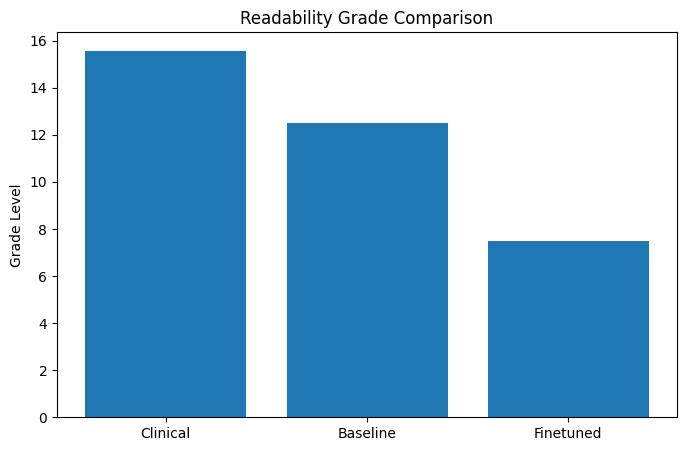

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    ["Clinical", "Baseline", "Finetuned"],
    [
        results["Clinical Grade Level"],
        results["Baseline Grade Level"],
        results["Finetuned Grade Level"]
    ]
)

plt.title("Readability Grade Comparison")
plt.ylabel("Grade Level")

plt.show()

In [ ]:
eval_df.to_csv("evaluation_results.csv", index=False)

In [ ]:
results_df.to_csv("evaluation_summary.csv", index=False)

In [ ]:
from google.colab import files

# Save full eval dataframe
eval_df[:20].to_csv("evaluation_results.csv", index=False)

# Save summary scores
results_df = pd.DataFrame(list(results.items()), columns=["Metric", "Score"])
results_df.to_csv("evaluation_summary.csv", index=False)

# Download both files
files.download("evaluation_results.csv")
files.download("evaluation_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Day 5- Inference Optimization

In [1]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [3]:
from google.colab import files
uploaded = files.upload()  # Upload mistral-medical-lora.zip

Saving mistral-medical-lora.zip to mistral-medical-lora (1).zip


In [4]:
!unzip mistral-medical-lora.zip

Archive:  mistral-medical-lora.zip
replace chat_template.jinja? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: chat_template.jinja     
  inflating: tokenizer.json          
  inflating: adapter_model.safetensors  
  inflating: tokenizer_config.json   
  inflating: adapter_config.json     
  inflating: README.md               


In [5]:
!mkdir -p mistral-medical-lora && mv adapter_config.json adapter_model.safetensors tokenizer.json tokenizer_config.json mistral-medical-lora/

In [6]:
!ls mistral-medical-lora  # Verify files are there

adapter_config.json	   tokenizer_config.json
adapter_model.safetensors  tokenizer.json


In [7]:
# !pip install peft==0.8.2 transformers==4.38.2 -qy  ## not this peft version

In [8]:
# !pip install peft==0.18.1 -q

In [9]:
# pip install -U bitsandbytes>=0.46.1

In [10]:
# import json
# with open("/content/mistral-medical-lora/adapter_config.json") as f:
#     config = json.load(f)
# print(json.dumps(config, indent=2))

In [11]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import torch

base_model_id = "mistralai/Mistral-7B-Instruct-v0.2"
lora_path = "/content/mistral-medical-lora"

# 4-bit config to fit within T4's 15GB VRAM
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(base_model_id)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_id,
    quantization_config=bnb_config,
    device_map="cuda:0"  # Force single GPU, no CPU offload
)

model = PeftModel.from_pretrained(base_model, lora_path)
model.eval()
print("Loaded successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

✅ Loaded successfully!


In [12]:
# 2. Prompt Template (same as training)

def build_prompt(text):
    return f"""### Instruction:
Simplify the following clinical text into patient-friendly explanation.

### Input:
{text}

### Response:
"""

In [13]:
# 3. Generate (LoRA inference)

def generate(text, model):
    prompt = build_prompt(text)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output = model.generate(
    **inputs,
    max_new_tokens=200,
    do_sample=True,
    temperature=0.3,
    top_p=0.9
)

    return tokenizer.decode(output[0], skip_special_tokens=True)

In [14]:
# 4. Merge LoRA → Base Model

merged_model = model.merge_and_unload()

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


In [15]:
# 5. Save Merged Model

save_path = "/content/merged_model"

merged_model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/merged_model/tokenizer_config.json',
 '/content/merged_model/chat_template.jinja',
 '/content/merged_model/tokenizer.json')

In [16]:
# 6. Reload for Fast Inference

fast_model = AutoModelForCausalLM.from_pretrained(
    save_path,
    torch_dtype=torch.float16,
    device_map="auto"
)
fast_model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
      )
    )
    (n

In [17]:
# 7. Latency Comparison

import time

sample = "The patient presents with myocardial infarction."

# LoRA
start = time.time()
generate(sample, model)
lora_time = time.time() - start

# Merged
start = time.time()
generate(sample, fast_model)
merged_time = time.time() - start

print(f"LoRA time: {lora_time:.2f}s")
print(f"Merged time: {merged_time:.2f}s")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


LoRA time: 11.06s
Merged time: 3.76s


In [18]:
# 8. Guardrails

def safe_generate(text, model):
    output = generate(text, model)

    # Basic guardrails
    if "diagnosis" in output.lower():
        output = "This system does not provide medical diagnosis.\n\n" + output

    return {
        "input": text,
        "output": output.strip(),
        "note": "Educational purpose only. Not medical advice."
    }